In [5]:
import zipfile
import os
import cv2

zip_path = "/content/archive (21).zip"
extract_path = "extracted_images"

# Define a common image size for resizing
IMAGE_SIZE = (224, 224) # Example size, you can adjust this

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images and resize them to a common dimension
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                # Resize the image to the common size
                img_resized = cv2.resize(img, IMAGE_SIZE)
                images.append(img_resized)

print("Total images loaded and resized:", len(images))

Total images loaded and resized: 506


In [19]:
import os
import cv2
import numpy as np

images = []
labels = []

for root, dirs, files in os.walk("extracted_images"):
    label = os.path.basename(root)

    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):

            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:

                # Resize
                img = cv2.resize(img, (128, 128))

                # Convert to Grayscale
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                # Normalize
                img = img / 255.0

                # Original image
                images.append(img)
                labels.append(label)

                # Flipped image
                flipped = cv2.flip(img, 1)

                images.append(flipped)
                labels.append(label)

print("Total images after augmentation:", len(images))

Total images after augmentation: 1012


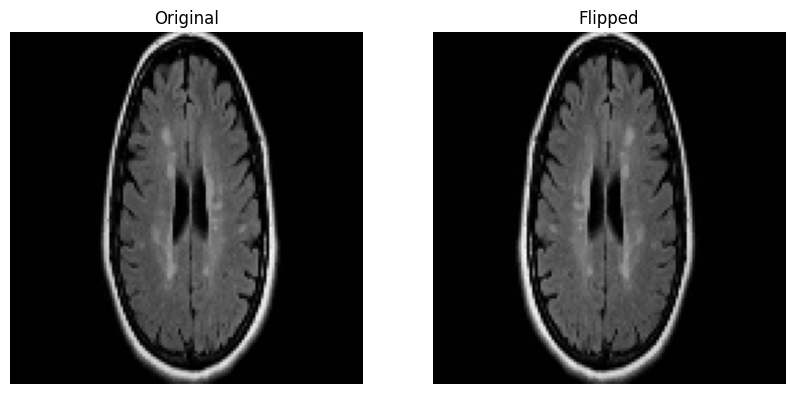

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(images[0], cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(images[1], cmap='gray')
plt.title("Flipped")
plt.axis("off")

plt.show()

In [21]:
X = np.array(images)

# Flatten images
X = X.reshape(X.shape[0], -1)

print("Shape of X:", X.shape)

Shape of X: (1012, 16384)


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(labels)

print("Classes:", le.classes_)

Classes: ['no' 'yes']


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score
)

In [25]:
images = []
labels = []

for root, dirs, files in os.walk("extracted_images"):

    label = os.path.basename(root)

    for file in files:

        if file.lower().endswith((".jpg",".jpeg",".png",".bmp")):

            img_path = os.path.join(root,file)

            img = cv2.imread(img_path)

            if img is not None:

                # Resize
                img = cv2.resize(img,(128,128))

                # Grayscale
                img = cv2.cvtColor(
                    img,
                    cv2.COLOR_BGR2GRAY
                )

                # Normalize
                img = img / 255.0

                # Original Image
                images.append(img)
                labels.append(label)

                # Horizontal Flip
                flipped = cv2.flip(img,1)

                images.append(flipped)
                labels.append(label)

print("Total Images:",len(images))

Total Images: 1012


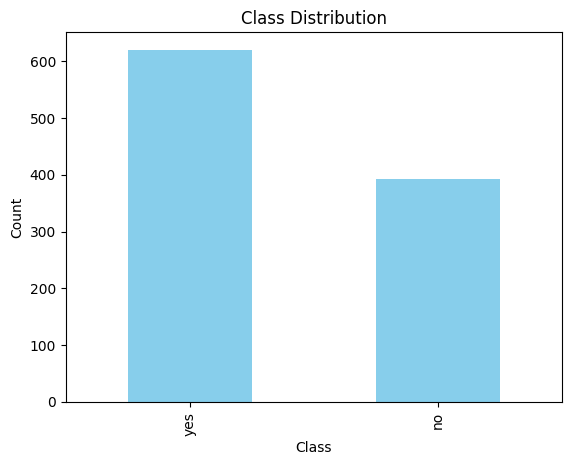

In [26]:
pd.Series(labels).value_counts().plot(
    kind='bar',
    color='skyblue'
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

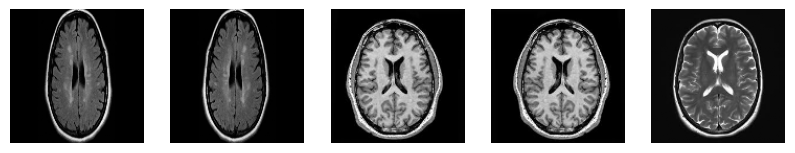

In [27]:
plt.figure(figsize=(10,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(images[i],cmap='gray')

    plt.axis('off')

plt.show()

In [28]:
X = np.array(images)

# Flatten images
X = X.reshape(X.shape[0],-1)

print("Feature Shape:",X.shape)

Feature Shape: (1012, 16384)


In [29]:
le = LabelEncoder()

y = le.fit_transform(labels)

print("Classes:",le.classes_)

Classes: ['no' 'yes']


In [30]:
X_df = pd.DataFrame(X)

skewness = X_df.skew()

print(skewness.head())

0    3.033803
1    3.789252
2    3.751794
3    4.173940
4    3.988068
dtype: float64


In [31]:
X = np.log1p(X)

In [32]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [33]:
X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(809, 16384)
(203, 16384)


In [34]:
lr_reg = LinearRegression()

lr_reg.fit(X_train,y_train)

pred_reg = lr_reg.predict(X_test)

pred_reg_binary = (pred_reg > 0.5).astype(int)

print("Linear Regression Accuracy:",
      accuracy_score(
          y_test,
          pred_reg_binary
      ))

Linear Regression Accuracy: 0.9704433497536946


In [35]:
print(
    "R2 Score:",
    r2_score(y_test,pred_reg)
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            pred_reg
        )
    )
)

R2 Score: 0.9099122110635238
RMSE: 0.14633941490394975


In [36]:
log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train,
    y_train
)

y_pred_log = log_model.predict(
    X_test
)

In [37]:
print(
    "Logistic Regression Accuracy:",
    accuracy_score(
        y_test,
        y_pred_log
    )
)

Logistic Regression Accuracy: 0.9704433497536946


In [38]:
print(
    classification_report(
        y_test,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        79
           1       0.97      0.98      0.98       124

    accuracy                           0.97       203
   macro avg       0.97      0.97      0.97       203
weighted avg       0.97      0.97      0.97       203



In [39]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test
)

In [40]:
print(
    "Random Forest Accuracy:",
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

Random Forest Accuracy: 0.9901477832512315


In [41]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        79
           1       0.98      1.00      0.99       124

    accuracy                           0.99       203
   macro avg       0.99      0.99      0.99       203
weighted avg       0.99      0.99      0.99       203



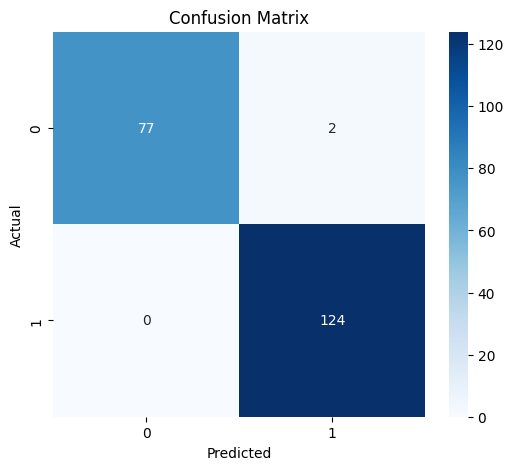

In [42]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [43]:
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',
     RandomForestClassifier(
         n_estimators=100,
         random_state=42
     ))
])

pipeline.fit(
    X_train,
    y_train
)

pipeline_pred = pipeline.predict(
    X_test
)

print(
    "Pipeline Accuracy:",
    accuracy_score(
        y_test,
        pipeline_pred
    )
)

Pipeline Accuracy: 0.9901477832512315


In [44]:
print("Linear Regression Accuracy:",
      accuracy_score(y_test,pred_reg_binary))

print("Logistic Regression Accuracy:",
      accuracy_score(y_test,y_pred_log))

print("Random Forest Accuracy:",
      accuracy_score(y_test,y_pred_rf))

Linear Regression Accuracy: 0.9704433497536946
Logistic Regression Accuracy: 0.9704433497536946
Random Forest Accuracy: 0.9901477832512315


In [45]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [72]:
from google.colab import files

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

Saving no.jpg to no.jpg


In [76]:
import cv2
import numpy as np

# Path of image to test
# The img_path variable is already set by the previous upload cell (vq44DH_-MaMB).
# We just need to prepend the content directory.
full_img_path = "/content/" + img_path

# Read image
img = cv2.imread(full_img_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Could not load image from {full_img_path}. Please ensure the file exists and is a valid image.")
else:
    # Same preprocessing used during training
    img = cv2.resize(img, (128,128))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255.0

    # Flatten image
    img = img.flatten()

    # Convert to array
    img = np.array(img).reshape(1,-1)

    # Apply same transformations used during training

    # Log transformation
    img = np.log1p(img)

    # Feature scaling
    img = scaler.transform(img)

    # Prediction
    prediction = rf_model.predict(img)

    # Convert numeric label back to original label
    result = le.inverse_transform(prediction)

    print("Prediction:", result[0])
    print("Accuracy:", np.max(probability)*100, "%")

    if result[0].lower() in ['yes','tumor','brain_tumor']:
        print("Brain Tumor Detected")
    else:
        print("No Brain Tumor Detected")

Prediction: no
Accuracy: 94.0 %
No Brain Tumor Detected


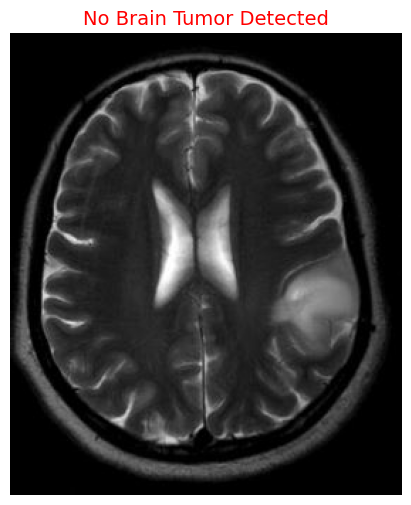

In [74]:
if result[0].lower() in ['yes', 'tumor', 'brain_tumor']:
    label = "Brain Tumor Detected"
else:
    label = "No Brain Tumor Detected"

plt.figure(figsize=(6,6))
plt.imshow(display_img)
plt.title(label, fontsize=14, color='red')
plt.axis('off')
plt.show()